# Mars-YOLO-15km: Interactive Inference & Explainable AI (XAI)
**Authors:** Pavan Mohan Neelamraju, Akshay Pratap Singh, Raghukanth STG

This interactive notebook provides a transparent, step-by-step demonstration of the geomorphometric crater delineation framework. 
It allows users to:
1. Load the optimized YOLOv8m weights.
2. Run automated boundary extraction on unseen THEMIS Day IR imagery.
3. Extract deep feature activations (Layer 22) to generate **2D Spatial Attention Maps (XAI)**, proving the model anchors to physical topographic lighting rather than superficial artifacts.

In [1]:
# [CELL 2] Setup, Imports, and Paths
import os
import random
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Enable inline plotting for Jupyter
%matplotlib inline

# Define paths relative to the notebooks/ directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
MODEL_PATH = os.path.join(BASE_DIR, 'models', 'best.pt')
VAL_IMAGES_DIR = os.path.join(BASE_DIR, 'data', 'images', 'val')

# Configure publication-grade plot settings for inline display
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'font.family': 'serif'
})

print(f"[*] Base Directory: {BASE_DIR}")
print(f"[*] Model Path: {MODEL_PATH}")
print(f"[*] Validation Data Path: {VAL_IMAGES_DIR}")

[*] Base Directory: d:\SDA5\code\Mars-YOLO-15km-Framework
[*] Model Path: d:\SDA5\code\Mars-YOLO-15km-Framework\models\best.pt
[*] Validation Data Path: d:\SDA5\code\Mars-YOLO-15km-Framework\data\images\val


### 1. Initialize the YOLOv8m Model & PyTorch Hook
To generate the Explainable AI (XAI) heatmap, we cannot treat the model as a black box. We must intercept the neural network's thought process *before* it mathematically flattens the image into a bounding box. 

We achieve this by registering a **PyTorch Forward Hook** on Layer 22 (the deepest spatial layer immediately prior to the YOLOv8 detection head).

In [2]:
# [CELL 4] Model Loading and Hook Registration
class InteractiveXAI:
    def __init__(self, model_path):
        print(f"[*] Loading YOLOv8m Geomorphometric Model...")
        self.model = YOLO(model_path)
        self.feature_maps = None
        self._register_hook()
        print("[+] Model loaded and Layer 22 Hook registered successfully.")

    def _hook_fn(self, module, input, output):
        # Intercept the 2D spatial feature map entering the Detection Head
        spatial_tensors = input[0]
        if isinstance(spatial_tensors, (list, tuple)):
            self.feature_maps = spatial_tensors[0]
        else:
            self.feature_maps = spatial_tensors
            
        if isinstance(self.feature_maps, (list, tuple)):
            self.feature_maps = self.feature_maps[0]

    def _register_hook(self):
        # Attach the hook to Layer 22
        pytorch_model = self.model.model
        target_layer = pytorch_model.model[22] 
        target_layer.register_forward_hook(self._hook_fn)

# Initialize our interactive extractor
xai_engine = InteractiveXAI(MODEL_PATH)

[*] Loading YOLOv8m Geomorphometric Model...
[+] Model loaded and Layer 22 Hook registered successfully.


### 2. Load a Sample THEMIS Image
Let's select a random tile from the validation dataset to ensure the model has never seen this specific terrain during training.

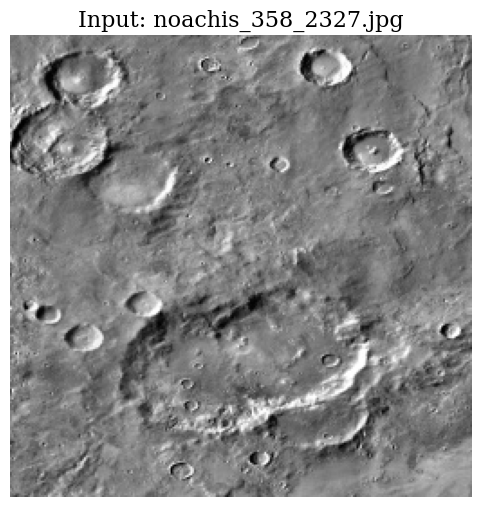

In [3]:
# [CELL 6] Load Sample Image
# Get all valid images from the validation folder
valid_images = [f for f in os.listdir(VAL_IMAGES_DIR) if f.endswith(('.jpg', '.png'))]

if not valid_images:
    raise FileNotFoundError(f"No images found in {VAL_IMAGES_DIR}. Please check your dataset.")

# Select a random image (or hardcode a specific filename here if you prefer)
sample_image_name = random.choice(valid_images)
img_path = os.path.join(VAL_IMAGES_DIR, sample_image_name)

# Read the image using OpenCV
original_img = cv2.imread(img_path)
rgb_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB) # Convert for Matplotlib

plt.figure(figsize=(6, 6))
plt.imshow(rgb_img)
plt.title(f"Input: {sample_image_name}")
plt.axis('off')
plt.show()

### 3. Execute Inference & Extract Saliency
We will now pass the image through the model. The network will output the geomorphometric bounding box, and our PyTorch hook will simultaneously capture the deep spatial activations (Layer 22) to generate the heatmap.

In [4]:
# [CELL 8] Run Inference and Process XAI Map
print("[*] Running YOLOv8m Inference...")
# Run standard detection with our strict 0.7 geomorphometric constraint
results = xai_engine.model.predict(img_path, conf=0.7, verbose=False)

# Extract the image with the predicted bounding boxes drawn on it
detection_img_bgr = results[0].plot()
detection_img = cv2.cvtColor(detection_img_bgr, cv2.COLOR_BGR2RGB)

print("[*] Processing Layer 22 Spatial Activations...")
# Process the captured feature maps into a 2D Heatmap
activation = torch.mean(xai_engine.feature_maps, dim=1).squeeze()
activation = activation.cpu().detach().numpy()

# Normalize to [0, 255]
activation = np.maximum(activation, 0)
activation = (activation - activation.min()) / (activation.max() - activation.min() + 1e-8)
activation = np.uint8(255 * activation)

# Resize heatmap to match the original image dimensions
H, W = original_img.shape[:2]
heatmap_resized = cv2.resize(activation, (W, H))

# Apply the Viridis scientific colormap
colormap = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_VIRIDIS)

# Create the Fusion Attention Map (60% Heatmap, 40% Original Image)
fusion_map_bgr = cv2.addWeighted(colormap, 0.6, original_img, 0.4, 0)
fusion_map = cv2.cvtColor(fusion_map_bgr, cv2.COLOR_BGR2RGB)

print("[+] Processing Complete.")

[*] Running YOLOv8m Inference...
[*] Processing Layer 22 Spatial Activations...
[+] Processing Complete.


### 4. Photogrammetric Proof
By comparing the native bounding box output (Center) with the XAI Fusion Map (Right), we prove the model calculates the spatial centroid based on the physical lighting gradients of the crater (illuminated rim crests vs. shadowed inner basins), completely ignoring surrounding geological noise.

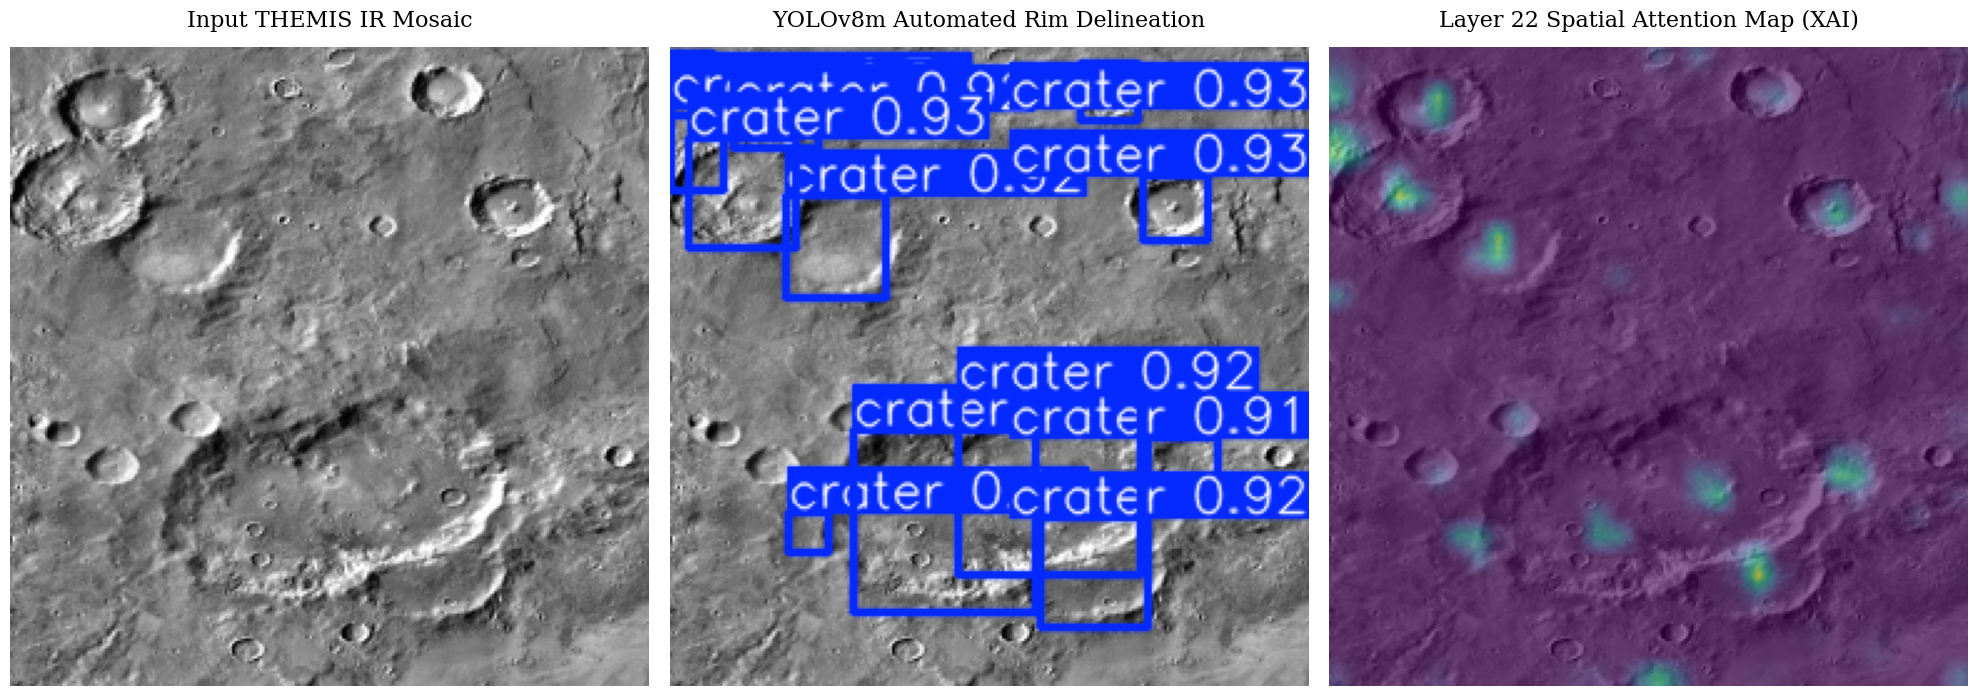

In [5]:
# [CELL 10] Display the Final Analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Panel 1: Original Image
axes[0].imshow(rgb_img)
axes[0].set_title("Input THEMIS IR Mosaic", pad=15)
axes[0].axis('off')

# Panel 2: YOLOv8m Delineation
axes[1].imshow(detection_img)
axes[1].set_title("YOLOv8m Automated Rim Delineation", pad=15)
axes[1].axis('off')

# Panel 3: XAI Fusion Map
axes[2].imshow(fusion_map)
axes[2].set_title("Layer 22 Spatial Attention Map (XAI)", pad=15)
axes[2].axis('off')

plt.tight_layout()
plt.show()